In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr

BASE_DIR = Path("..")
PROC_DIR = BASE_DIR / "data" / "processed"
FIG_DIR  = BASE_DIR / "results" / "figures" / "paper"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Publication style
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         11,
    'axes.titlesize':    12,
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'legend.fontsize':   10,
    'figure.dpi':        150,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

# Load all results
gdsc2       = pd.read_csv(PROC_DIR / "gdsc2_matched.csv")
overlap     = pd.read_csv(PROC_DIR / "gdsc2_jump_overlap.csv")
morgan      = pd.read_csv(PROC_DIR / "morgan_fingerprints.csv")
consensus   = pd.read_csv(PROC_DIR / "consensus_profiles.csv")
ic50        = pd.read_csv(PROC_DIR / "gdsc2_ic50_matrix.csv", index_col=0)
shap_feat   = pd.read_csv(BASE_DIR / "results" / "shap_feature_importance.csv")
shap_path   = pd.read_csv(BASE_DIR / "results" / "shap_pathway_summary.csv")
tanimoto    = np.load(PROC_DIR / "tanimoto_similarity.npy")
cosine      = np.load(PROC_DIR / "morpho_cosine_similarity.npy")
ic50_sim    = np.load(PROC_DIR / "ic50_cosine_similarity.npy")

model_results = {
    'Structure\nonly':   {'r': 0.3333, 'rmse': 2.4652},
    'Morphology\nonly':  {'r': 0.6002, 'rmse': 2.0883},
    'Concatenation':     {'r': 0.6085, 'rmse': 2.0542},
    'Cross-\nAttention': {'r': 0.5972, 'rmse': 2.0656},
    'Gated\nFusion':     {'r': 0.5848, 'rmse': 2.0561}
}

print("all data loaded.")
print(f"figures will be saved to: {FIG_DIR}")

all data loaded.
figures will be saved to: ..\results\figures\paper


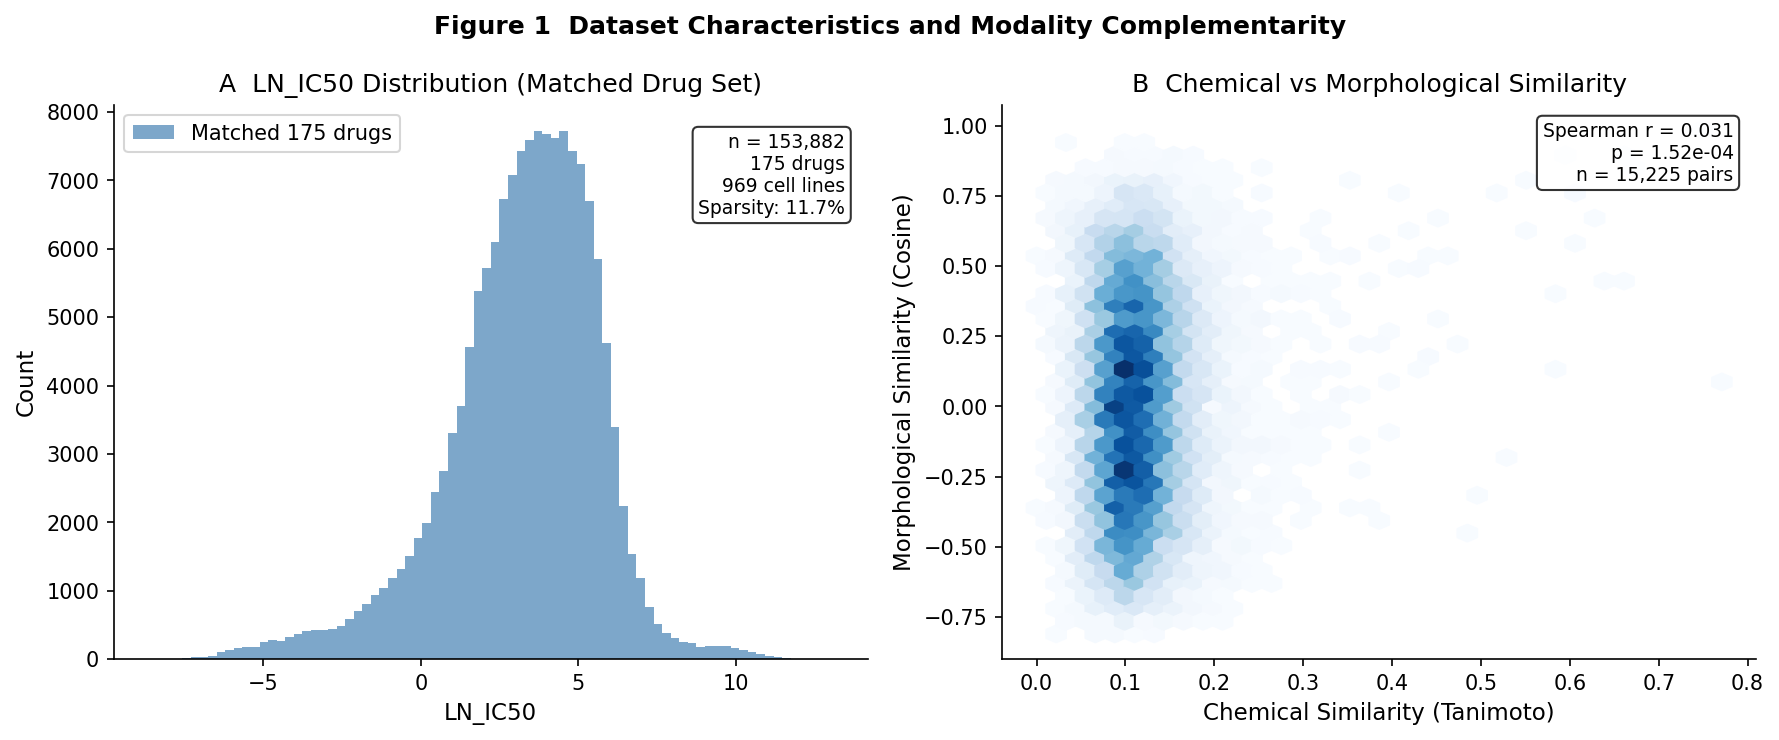

saved: fig1_dataset_complementarity.png


In [2]:
# Figure 1: Dataset overview and modality complementarity (2-panel)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# panel A: LN_IC50 distribution full vs matched
ax = axes[0]
ax.hist(pd.read_csv(PROC_DIR / "gdsc2_matched.csv")['LN_IC50'],
        bins=80, alpha=0.7, color='steelblue', label='Matched 175 drugs')
ax.set_xlabel("LN_IC50")
ax.set_ylabel("Count")
ax.set_title("A  LN_IC50 Distribution (Matched Drug Set)")
ax.legend()
ax.text(0.97, 0.95, f"n = 153,882\n175 drugs\n969 cell lines\nSparsity: 11.7%",
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# panel B: Chemical vs morphological similarity
ax = axes[1]
idx = np.triu_indices(175, k=1)
tanimoto_flat = tanimoto[idx]
cosine_flat   = cosine[idx]
r, p = spearmanr(tanimoto_flat, cosine_flat)

ax.hexbin(tanimoto_flat, cosine_flat, gridsize=35, cmap='Blues', mincnt=1)
ax.set_xlabel("Chemical Similarity (Tanimoto)")
ax.set_ylabel("Morphological Similarity (Cosine)")
ax.set_title("B  Chemical vs Morphological Similarity")
ax.text(0.97, 0.97,
        f"Spearman r = {r:.3f}\np = {p:.2e}\nn = {len(tanimoto_flat):,} pairs",
        transform=ax.transAxes, ha='right', va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.suptitle("Figure 1  Dataset Characteristics and Modality Complementarity", 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_dataset_complementarity.png", dpi=300, bbox_inches='tight')
plt.show()
print("saved: fig1_dataset_complementarity.png")

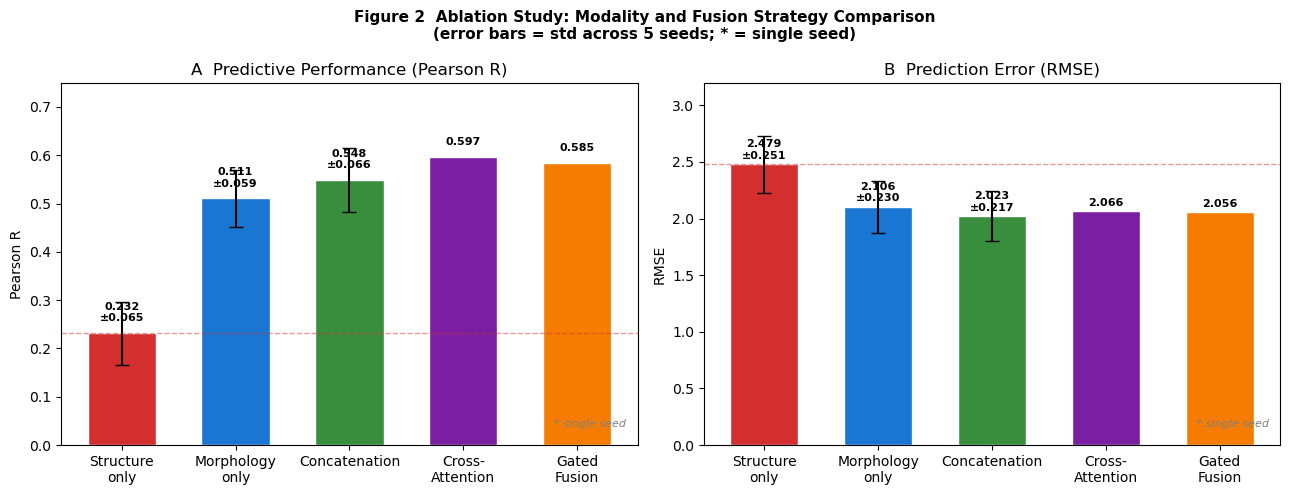

Saved: fig2_ablation_results_final.png


In [2]:
# Figure 2: Model performance ablation

import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path("..")
FIG_DIR  = BASE_DIR / "results" / "figures" / "paper"

with open(BASE_DIR / "results" / "final_results.json") as f:
    final = json.load(f)

ms = final['mlp_multiseed']
ss = final['single_seed_models']

conditions = ['Structure\nonly', 'Morphology\nonly', 'Concatenation',
              'Cross-\nAttention', 'Gated\nFusion']

r_means = [
    ms['structure_only']['r_mean'],
    ms['morphology_only']['r_mean'],
    ms['concatenation']['r_mean'],
    ss['cross_attention']['pearson_r'],
    ss['gated_fusion']['pearson_r']
]
r_stds = [
    ms['structure_only']['r_std'],
    ms['morphology_only']['r_std'],
    ms['concatenation']['r_std'],
    None, None
]
rmse_means = [
    ms['structure_only']['rmse_mean'],
    ms['morphology_only']['rmse_mean'],
    ms['concatenation']['rmse_mean'],
    ss['cross_attention']['rmse'],
    ss['gated_fusion']['rmse']
]
rmse_stds = [
    ms['structure_only']['rmse_std'],
    ms['morphology_only']['rmse_std'],
    ms['concatenation']['rmse_std'],
    None, None
]

colors = ['#d32f2f', '#1976d2', '#388e3c', '#7b1fa2', '#f57c00']
x = np.arange(len(conditions))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: Pearson R
ax = axes[0]
bars = ax.bar(x, r_means, color=colors, width=0.6, edgecolor='white')

# Error bars only for multi-seed models
for i, (mean, std) in enumerate(zip(r_means, r_stds)):
    if std is not None:
        ax.errorbar(x[i], mean, yerr=std, fmt='none',
                   color='black', capsize=5, linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels(conditions)
ax.set_ylabel("Pearson R")
ax.set_title("A  Predictive Performance (Pearson R)")
ax.set_ylim(0, 0.75)
ax.axhline(y=r_means[0], color='#d32f2f', linestyle='--', linewidth=1, alpha=0.5)

for i, (bar, val, std) in enumerate(zip(bars, r_means, r_stds)):
    label = f'{val:.3f}' if std is None else f'{val:.3f}\n±{std:.3f}'
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02,
            label, ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.text(0.98, 0.05, '* single seed', transform=ax.transAxes,
        ha='right', fontsize=8, color='gray', style='italic')

# Panel B: RMSE
ax = axes[1]
bars = ax.bar(x, rmse_means, color=colors, width=0.6, edgecolor='white')

for i, (mean, std) in enumerate(zip(rmse_means, rmse_stds)):
    if std is not None:
        ax.errorbar(x[i], mean, yerr=std, fmt='none',
                   color='black', capsize=5, linewidth=1.5)

ax.set_xticks(x)
ax.set_xticklabels(conditions)
ax.set_ylabel("RMSE")
ax.set_title("B  Prediction Error (RMSE)")
ax.set_ylim(0, 3.2)
ax.axhline(y=rmse_means[0], color='#d32f2f', linestyle='--', linewidth=1, alpha=0.5)

for i, (bar, val, std) in enumerate(zip(bars, rmse_means, rmse_stds)):
    label = f'{val:.3f}' if std is None else f'{val:.3f}\n±{std:.3f}'
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.03,
            label, ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.text(0.98, 0.05, '* single seed', transform=ax.transAxes,
        ha='right', fontsize=8, color='gray', style='italic')

plt.suptitle("Figure 2  Ablation Study: Modality and Fusion Strategy Comparison\n"
             "(error bars = std across 5 seeds; * = single seed)",
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_ablation_results_final.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig2_ablation_results_final.png")

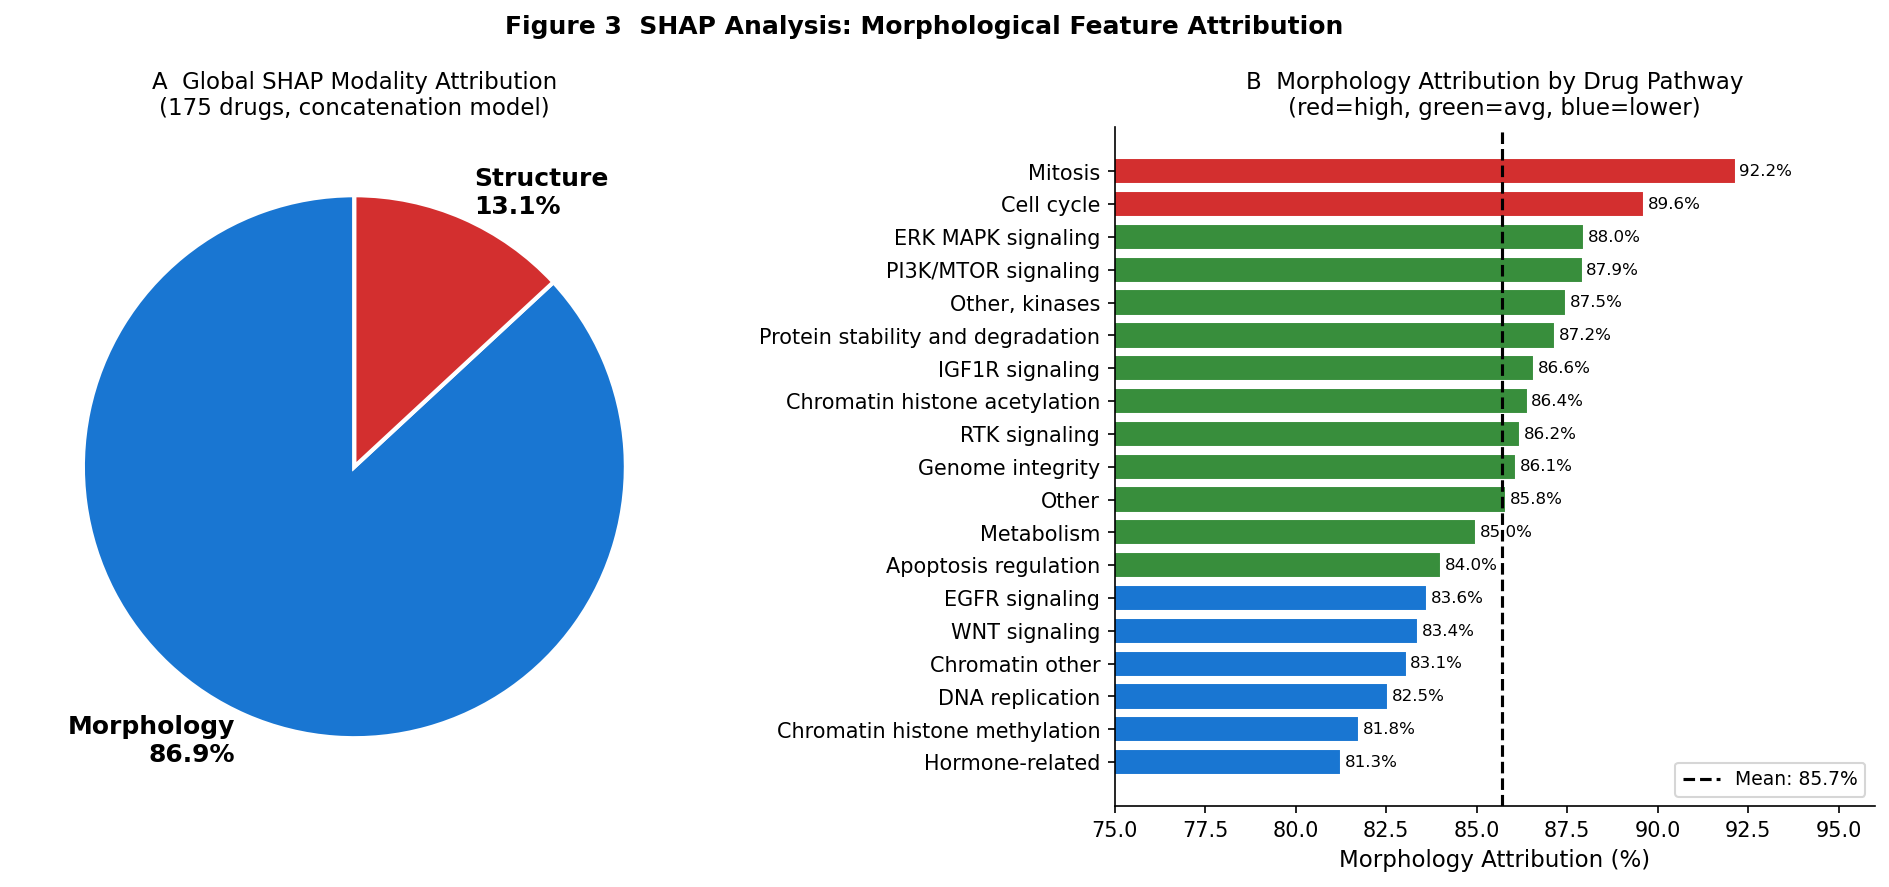

Saved: fig3_shap_attribution.png


In [8]:
# Figure 3: SHAP modality attribution and pathway analysis (2-panel)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Panel A
ax = axes[0]
sizes  = [86.9, 13.1]
labels = ['Morphology\n86.9%', 'Structure\n13.1%']
colors_pie = ['#1976d2', '#d32f2f']
wedges, texts = ax.pie(sizes, labels=labels, colors=colors_pie,
                        startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')
ax.set_title("A  Global SHAP Modality Attribution\n(175 drugs, concatenation model)",
             fontsize=11)

# Panel B
ax = axes[1]
shap_sorted = shap_path.sort_values('morpho_pct', ascending=True).reset_index(drop=True)

bar_colors = ['#d32f2f' if v > 88 else '#1976d2' if v < 84 else '#388e3c'
              for v in shap_sorted['morpho_pct']]

ax.barh(shap_sorted['pathway'], shap_sorted['morpho_pct'],
        color=bar_colors, edgecolor='white')
ax.axvline(x=shap_sorted['morpho_pct'].mean(), color='black',
           linestyle='--', linewidth=1.5,
           label=f"Mean: {shap_sorted['morpho_pct'].mean():.1f}%")
ax.set_xlabel("Morphology Attribution (%)")
ax.set_title("B  Morphology Attribution by Drug Pathway\n(red=high, green=avg, blue=lower)",
             fontsize=11)
ax.set_xlim(75, 96)
ax.legend(fontsize=9)
for i, val in enumerate(shap_sorted['morpho_pct']):
    ax.text(val + 0.1, i, f'{val:.1f}%', va='center', fontsize=8)

plt.suptitle("Figure 3  SHAP Analysis: Morphological Feature Attribution",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_shap_attribution.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig3_shap_attribution.png")

SHAP morpho: (175, 3178)
Drug names:  175


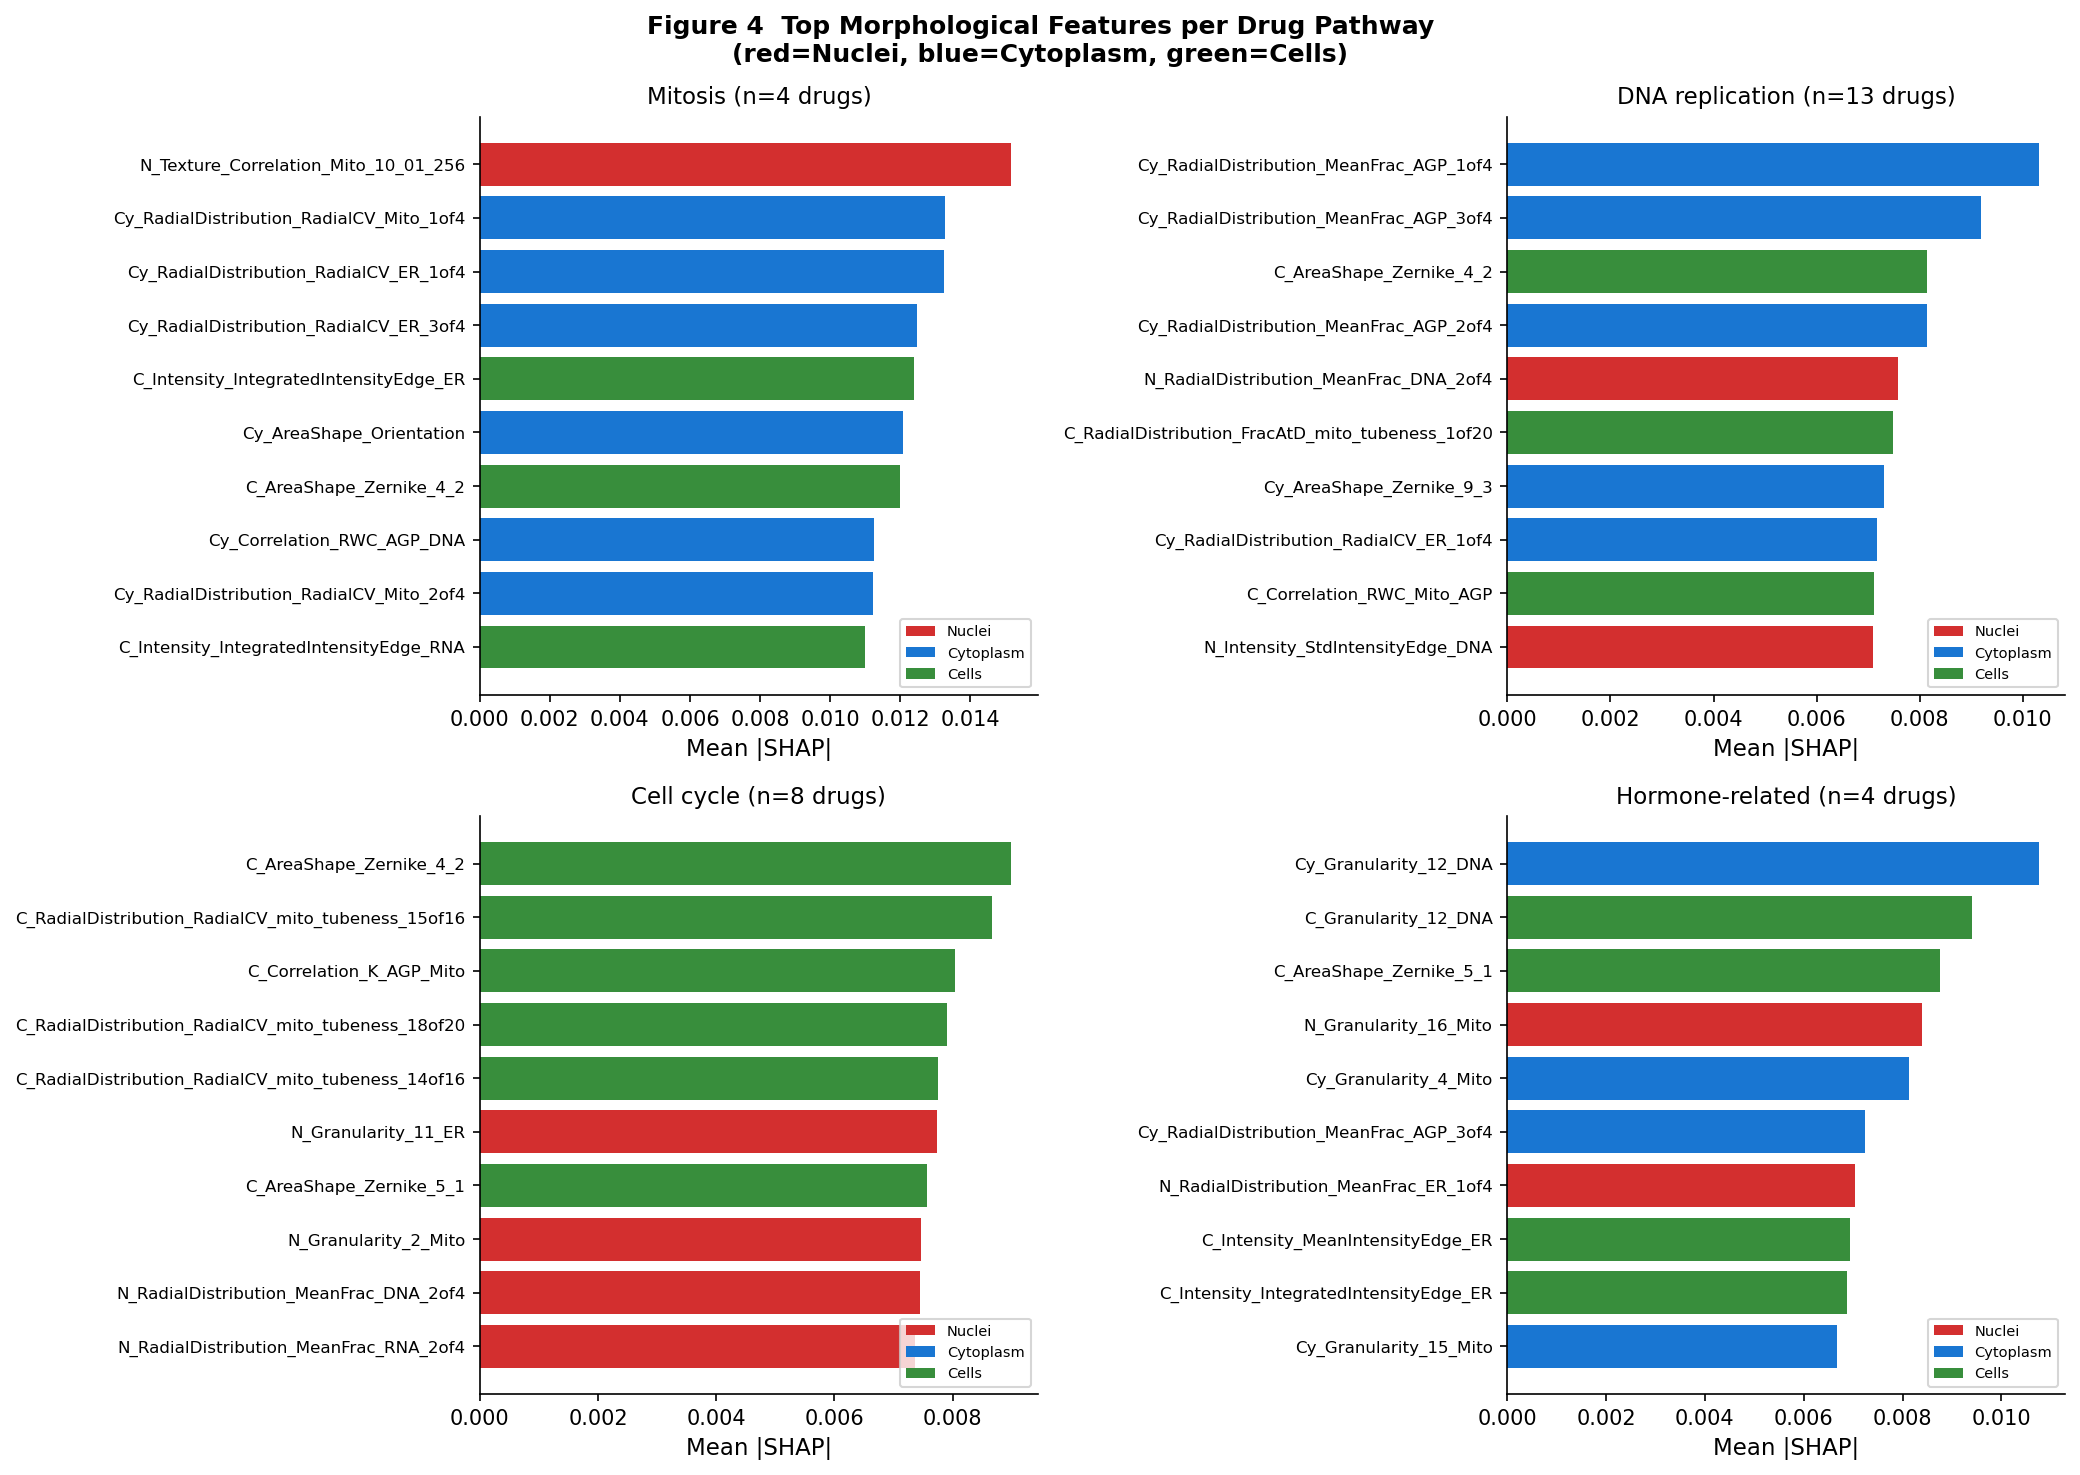

Saved: fig4_shap_per_pathway.png


In [12]:
# Figure 4: Per-pathway top morphological features

shap_morpho = np.load(BASE_DIR / "results" / "shap_morpho_values.npy")
shap_morgan = np.load(BASE_DIR / "results" / "shap_morgan_values.npy")

master      = pd.read_csv(PROC_DIR / "training_table.csv")
all_cols    = master.columns.tolist()
morpho_cols = [c for c in all_cols if c.startswith('Cells_')
               or c.startswith('Nuclei_')
               or c.startswith('Cytoplasm_')]
drug_names  = master['drug_name'].values
drug_index  = {name: i for i, name in enumerate(drug_names)}

pathway_map = pd.read_csv(PROC_DIR / "gdsc2_matched.csv")[['DRUG_NAME','PATHWAY_NAME']]\
    .drop_duplicates().rename(columns={'DRUG_NAME':'drug_name','PATHWAY_NAME':'pathway'})
drug_df = pd.DataFrame({'drug_name': drug_names})\
    .merge(pathway_map, on='drug_name', how='left')

print(f"SHAP morpho: {shap_morpho.shape}")
print(f"Drug names:  {len(drug_names)}")

focus_pathways = ['Mitosis', 'DNA replication', 'Cell cycle', 'Hormone-related']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, pathway in zip(axes, focus_pathways):
    pathway_drugs = drug_df[drug_df['pathway'] == pathway]['drug_name'].tolist()
    pathway_idx   = [drug_index[d] for d in pathway_drugs if d in drug_index]

    pathway_morpho_shap = np.abs(shap_morpho[pathway_idx]).mean(axis=0)
    top_idx  = np.argsort(pathway_morpho_shap)[-10:][::-1]
    top_feats = [morpho_cols[i] for i in top_idx]
    top_vals  = pathway_morpho_shap[top_idx]

    short = [f.replace('Cells_', 'C_').replace('Nuclei_', 'N_')
              .replace('Cytoplasm_', 'Cy_') for f in top_feats]

    compartment_colors = []
    for f in top_feats:
        if f.startswith('Nuclei'):
            compartment_colors.append('#d32f2f')
        elif f.startswith('Cytoplasm'):
            compartment_colors.append('#1976d2')
        else:
            compartment_colors.append('#388e3c')

    ax.barh(short[::-1], top_vals[::-1], color=compartment_colors[::-1])
    ax.set_title(f"{pathway} (n={len(pathway_idx)} drugs)", fontsize=11)
    ax.set_xlabel("Mean |SHAP|")
    ax.tick_params(axis='y', labelsize=8)

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#d32f2f', label='Nuclei'),
        Patch(facecolor='#1976d2', label='Cytoplasm'),
        Patch(facecolor='#388e3c', label='Cells')
    ]
    ax.legend(handles=legend_elements, fontsize=7, loc='lower right')

plt.suptitle("Figure 4  Top Morphological Features per Drug Pathway\n"
             "(red=Nuclei, blue=Cytoplasm, green=Cells)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_shap_per_pathway.png", dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig4_shap_per_pathway.png")

In [3]:
print("Paper figures generated:")
print(f"\n  fig1_dataset_complementarity.png")
print(f"    Panel A: LN_IC50 distribution")
print(f"    Panel B: Chemical vs morphological similarity (r=0.031)")
print(f"\n  fig2_ablation_results.png")
print(f"    Panel A: Pearson R across 5 conditions")
print(f"    Panel B: RMSE across 5 conditions")
print(f"\n  fig3_shap_attribution.png")
print(f"    Panel A: Global modality attribution (86.9% morphology)")
print(f"    Panel B: Pathway-level morphology attribution (81-92%)")
print(f"\n  fig4_shap_per_pathway.png")
print(f"    Top 10 features per pathway colored by compartment")

print(f"\nAll figures saved to: {FIG_DIR}")

# List all paper figures
print(f"\nFiles in paper figures directory:")
for f in sorted(FIG_DIR.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size/1e3:.0f} KB)")


Paper figures generated:

  fig1_dataset_complementarity.png
    Panel A: LN_IC50 distribution
    Panel B: Chemical vs morphological similarity (r=0.031)

  fig2_ablation_results.png
    Panel A: Pearson R across 5 conditions
    Panel B: RMSE across 5 conditions

  fig3_shap_attribution.png
    Panel A: Global modality attribution (86.9% morphology)
    Panel B: Pathway-level morphology attribution (81-92%)

  fig4_shap_per_pathway.png
    Top 10 features per pathway colored by compartment

All figures saved to: ..\results\figures\paper

Files in paper figures directory:
  fig1_dataset_complementarity.png  (298 KB)
  fig2_ablation_results.png  (154 KB)
  fig2_ablation_results_final.png  (191 KB)
  fig3_shap_attribution.png  (361 KB)
  fig4_shap_per_pathway.png  (496 KB)
